# Overview of the ML-OPF Research Landscape

This notebook characterizes the broader academic ML-OPF literature
retrieved from Scopus before the application of patent- and policy-citation
filters.

The full Scopus corpus provides the academic baseline against which the
patent-cited and policy-cited subsets are subsequently interpreted.

The analysis covers:

1. publication growth;
2. leading publication sources;
3. leading authors;
4. geographic distribution of the literature; and
5. the principal academic research themes.

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ---------------------------------------------------------
# Project directories
# ---------------------------------------------------------

NOTEBOOK_DIR = Path.cwd()

if NOTEBOOK_DIR.name == "notebooks":
    PROJECT_DIR = NOTEBOOK_DIR.parent
else:
    PROJECT_DIR = NOTEBOOK_DIR


DATA_DIR = (
    PROJECT_DIR
    / "data"
)

SCOPUS_DIR = (
    DATA_DIR
    / "scopus"
)

OUTPUT_DIR = (
    PROJECT_DIR
    / "output"
)

LANDSCAPE_DIR = (
    OUTPUT_DIR
    / "scopus_research_landscape"
)

TABLE_DIR = (
    LANDSCAPE_DIR
    / "tables"
)

FIGURE_DIR = (
    LANDSCAPE_DIR
    / "figures"
)


for directory in [
    LANDSCAPE_DIR,
    TABLE_DIR,
    FIGURE_DIR,
]:

    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


SCOPUS_FILE = (
    SCOPUS_DIR
    / "scopus_full.xlsx"
)


print("Project directory :", PROJECT_DIR)
print("Scopus file       :", SCOPUS_FILE)
print("Output directory  :", LANDSCAPE_DIR)


## 1. Load and Validate Scopus Data

The complete Scopus dataset is loaded as the academic baseline for the
research-landscape analysis. No patent- or policy-citation filter is applied
at this stage.

In [ ]:
# ---------------------------------------------------------
# Load Scopus academic baseline
# ---------------------------------------------------------

scopus = pd.read_excel(
    SCOPUS_FILE
)


# ---------------------------------------------------------
# Create cleaned publication year
# ---------------------------------------------------------

scopus[
    "Year_clean"
] = pd.to_numeric(
    scopus["Year"],
    errors="coerce",
)


# ---------------------------------------------------------
# Diagnostics
# ---------------------------------------------------------

print("SCOPUS ACADEMIC BASELINE")
print("=" * 40)

print(
    "Documents :",
    f"{len(scopus):,}"
)

print(
    "Columns   :",
    f"{len(scopus.columns):,}"
)

print()

print(
    "Valid years   :",
    f"{scopus['Year_clean'].notna().sum():,}"
)

print(
    "Missing years :",
    f"{scopus['Year_clean'].isna().sum():,}"
)

print()

print("Columns:")

for column in scopus.columns:

    print(
        " -",
        column
    )

In [12]:
PATENT_FILE = (
    DATA_DIR
    / "lda"
    / "lens_from_scopus_scholar.xlsx"
)

POLICY_FILE = (
    DATA_DIR
    / "lda"
    / "overton_from_scopus_scholar.xlsx"
)


patent_cited = pd.read_excel(
    PATENT_FILE
)

policy_cited = pd.read_excel(
    POLICY_FILE
)


print(
    "Patent-cited documents:",
    f"{len(patent_cited):,}"
)

print(
    "Policy-cited documents:",
    f"{len(policy_cited):,}"
)

Patent-cited documents: 778
Policy-cited documents: 392


## 2. Publication Growth

The temporal development of the academic ML-OPF literature is examined using
the complete Scopus corpus. Publications are counted by publication year
without applying the subsequent patent- or policy-citation filters.

The resulting time series provides the academic baseline for understanding
the growth of the research field and for subsequently interpreting the
citation-selected patent and policy subsets.

In [ ]:
# ---------------------------------------------------------
# Annual publication counts
# Exclude 2027 because coverage is incomplete
# ---------------------------------------------------------

MAX_ANALYSIS_YEAR = 2026


publication_by_year = (
    scopus
    .dropna(
        subset=["Year_clean"]
    )
    .loc[
        lambda df:
            df["Year_clean"]
            <= MAX_ANALYSIS_YEAR
    ]
    .assign(
        Year=lambda df:
            df["Year_clean"]
            .astype(int)
    )
    .groupby(
        "Year"
    )
    .size()
    .reset_index(
        name="Documents"
    )
    .sort_values(
        "Year"
    )
    .reset_index(
        drop=True
    )
)


# ---------------------------------------------------------
# Cumulative publication count
# ---------------------------------------------------------

publication_by_year[
    "Cumulative_Documents"
] = (
    publication_by_year[
        "Documents"
    ]
    .cumsum()
)


# ---------------------------------------------------------
# Diagnostics
# ---------------------------------------------------------

n_excluded_future = (
    scopus[
        "Year_clean"
    ]
    .gt(
        MAX_ANALYSIS_YEAR
    )
    .sum()
)


print("SCOPUS PUBLICATION GROWTH")
print("=" * 45)

print(
    "Documents included :",
    f"{publication_by_year['Documents'].sum():,}"
)

print(
    "Documents excluded :",
    f"{n_excluded_future:,}"
)

print(
    "Years represented  :",
    len(
        publication_by_year
    )
)

print(
    "Earliest year      :",
    publication_by_year[
        "Year"
    ].min()
)

print(
    "Latest year        :",
    publication_by_year[
        "Year"
    ].max()
)

print()

display(
    publication_by_year
)

In [ ]:
publication_by_year.to_csv(
    TABLE_DIR
    / "scopus_publication_growth.csv",
    index=False,
)

print(
    "Saved:",
    TABLE_DIR
    / "scopus_publication_growth.csv"
)

In [ ]:
print("ANNUAL PUBLICATION COUNTS")
print("=" * 45)

for _, row in publication_by_year.iterrows():

    print(
        f"{int(row['Year'])}: "
        f"{int(row['Documents']):,}"
    )

In [ ]:
fig, ax = plt.subplots(
    figsize=(8.5, 5.0)
)

ax.plot(
    publication_by_year["Year"],
    publication_by_year["Documents"],
    marker="o",
    linewidth=1.5,
)

ax.set_xlabel(
    "Publication year"
)

ax.set_ylabel(
    "Number of publications"
)

ax.set_title(
    "Annual Growth of ML-OPF Research"
)

ax.grid(
    alpha=0.25
)

fig.tight_layout()


publication_growth_figure = (
    FIGURE_DIR
    / "scopus_publication_growth.pdf"
)

fig.savefig(
    publication_growth_figure,
    format="pdf",
    bbox_inches="tight",
)

print(
    "Saved:",
    publication_growth_figure
)

plt.show()

In [14]:
# ---------------------------------------------------------
# Construct annual Scopus / patent / policy comparison
# ---------------------------------------------------------

PLOT_START_YEAR = 2015
PLOT_END_YEAR = 2026


# ---------------------------------------------------------
# Helper: clean publication year
# ---------------------------------------------------------

def clean_year(series):

    return pd.to_numeric(
        series,
        errors="coerce",
    )


# ---------------------------------------------------------
# Ensure clean year columns exist
# ---------------------------------------------------------

scopus["Year_clean"] = clean_year(
    scopus["Year"]
)

patent_cited["Year_clean"] = clean_year(
    patent_cited["Year"]
)

policy_cited["Year_clean"] = clean_year(
    policy_cited["Year"]
)


# ---------------------------------------------------------
# Scopus annual publication counts
# ---------------------------------------------------------

scopus_yearly = (
    scopus
    .dropna(
        subset=["Year_clean"]
    )
    .loc[
        lambda df:
            df["Year_clean"].between(
                PLOT_START_YEAR,
                PLOT_END_YEAR,
            )
    ]
    .assign(
        Year=lambda df:
            df["Year_clean"].astype(int)
    )
    .groupby(
        "Year"
    )
    .size()
    .reset_index(
        name="Documents"
    )
)


# ---------------------------------------------------------
# Patent-cited scholarly publications by year
# ---------------------------------------------------------

patent_yearly = (
    patent_cited
    .dropna(
        subset=["Year_clean"]
    )
    .loc[
        lambda df:
            df["Year_clean"].between(
                PLOT_START_YEAR,
                PLOT_END_YEAR,
            )
    ]
    .assign(
        Year=lambda df:
            df["Year_clean"].astype(int)
    )
    .groupby(
        "Year"
    )
    .size()
    .reset_index(
        name="Patent_Cited"
    )
)


# ---------------------------------------------------------
# Policy-cited scholarly publications by year
# ---------------------------------------------------------

policy_yearly = (
    policy_cited
    .dropna(
        subset=["Year_clean"]
    )
    .loc[
        lambda df:
            df["Year_clean"].between(
                PLOT_START_YEAR,
                PLOT_END_YEAR,
            )
    ]
    .assign(
        Year=lambda df:
            df["Year_clean"].astype(int)
    )
    .groupby(
        "Year"
    )
    .size()
    .reset_index(
        name="Policy_Cited"
    )
)


# ---------------------------------------------------------
# Merge all three annual series
# ---------------------------------------------------------

citation_by_year = (
    scopus_yearly
    .merge(
        patent_yearly,
        on="Year",
        how="left",
    )
    .merge(
        policy_yearly,
        on="Year",
        how="left",
    )
    .sort_values(
        "Year"
    )
    .reset_index(
        drop=True
    )
)


# ---------------------------------------------------------
# Years with no patent/policy-cited publications = 0
# ---------------------------------------------------------

citation_by_year[
    [
        "Patent_Cited",
        "Policy_Cited",
    ]
] = (
    citation_by_year[
        [
            "Patent_Cited",
            "Policy_Cited",
        ]
    ]
    .fillna(0)
    .astype(int)
)


# ---------------------------------------------------------
# Annual citation shares
# ---------------------------------------------------------

citation_by_year[
    "Patent_Rate"
] = (
    100
    * citation_by_year[
        "Patent_Cited"
    ]
    / citation_by_year[
        "Documents"
    ]
)


citation_by_year[
    "Policy_Rate"
] = (
    100
    * citation_by_year[
        "Policy_Cited"
    ]
    / citation_by_year[
        "Documents"
    ]
)


# ---------------------------------------------------------
# Diagnostics
# ---------------------------------------------------------

print("ANNUAL EXTERNAL CITATION PATHWAYS")
print("=" * 55)

print(
    "Year range:",
    f"{citation_by_year['Year'].min()}-"
    f"{citation_by_year['Year'].max()}"
)

print(
    "Scopus publications:",
    f"{citation_by_year['Documents'].sum():,}"
)

print(
    "Patent-cited:",
    f"{citation_by_year['Patent_Cited'].sum():,}"
)

print(
    "Policy-cited:",
    f"{citation_by_year['Policy_Cited'].sum():,}"
)

print()

display(
    citation_by_year
)

ANNUAL EXTERNAL CITATION PATHWAYS
Year range: 2015-2026
Scopus publications: 15,346
Patent-cited: 695
Policy-cited: 362



,Year,Documents,Patent_Cited,Policy_Cited,Patent_Rate,Policy_Rate
0,2015,171,18,14,10.526316,8.187135
1,2016,207,22,9,10.628019,4.347826
2,2017,281,22,26,7.829181,9.252669
3,2018,432,45,16,10.416667,3.703704
4,2019,591,49,46,8.291032,7.783418
5,2020,841,91,38,10.820452,4.518430
6,2021,1133,97,49,8.561342,4.324801
7,2022,1505,101,47,6.710963,3.122924
8,2023,1859,86,50,4.626143,2.689618
9,2024,2443,92,46,3.765862,1.882931


Saved: m:\projects_latex\review_paper_2\output\scopus_research_landscape\figures\academic_growth_patent_policy_annotated.pdf


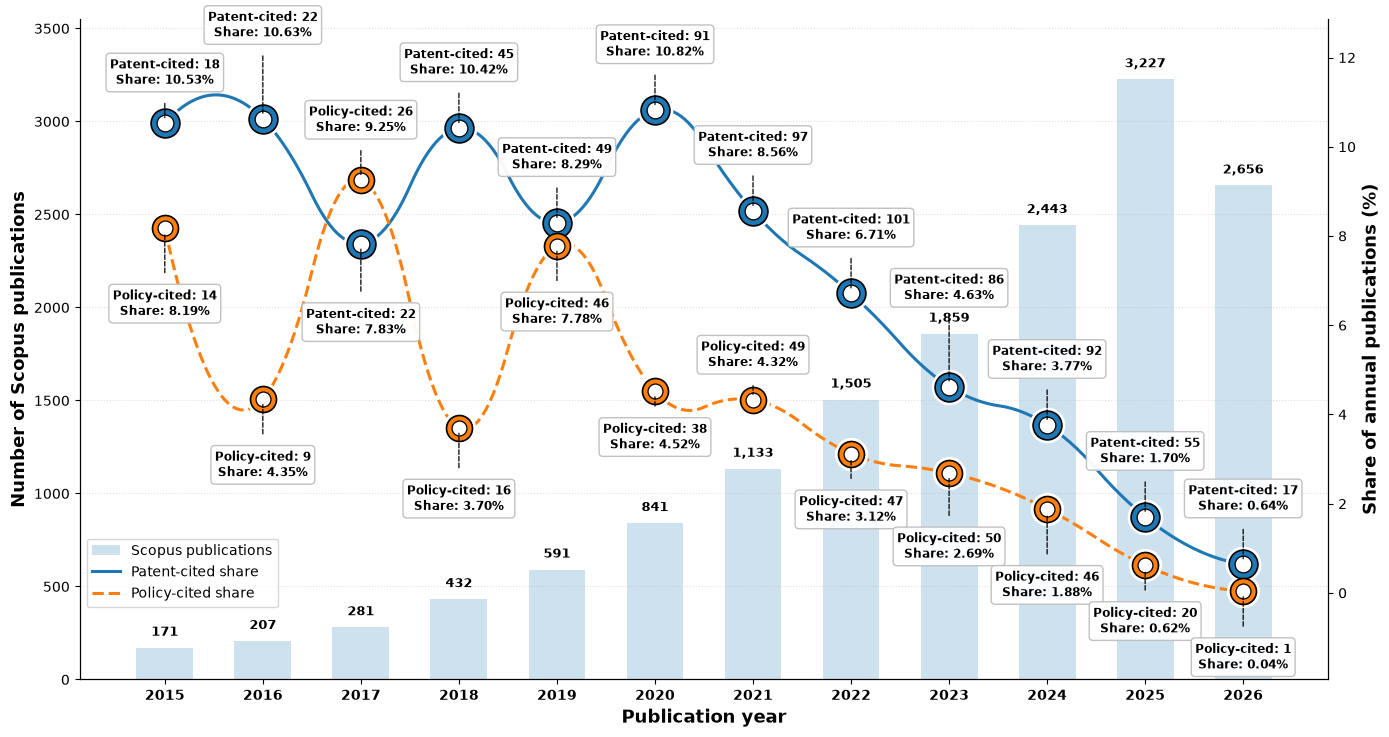

In [15]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import make_interp_spline


# =====================================================================
# CONFIGURATION
# =====================================================================

PLOT_START_YEAR = 2015
PLOT_END_YEAR = 2026


data = (
    citation_by_year[
        citation_by_year["Year"].between(
            PLOT_START_YEAR,
            PLOT_END_YEAR,
        )
    ]
    .copy()
    .reset_index(drop=True)
)


x = np.arange(len(data))

years = data["Year"].to_numpy()
publications = data["Documents"].to_numpy()

patent_counts = data["Patent_Cited"].to_numpy()
policy_counts = data["Policy_Cited"].to_numpy()

patent_rate = data["Patent_Rate"].to_numpy()
policy_rate = data["Policy_Rate"].to_numpy()


# =====================================================================
# FIGURE
# =====================================================================

fig, ax1 = plt.subplots(
    figsize=(14, 7.5),
    facecolor="white",
)

ax1.set_facecolor("white")


# =====================================================================
# LEFT AXIS — SCOPUS PUBLICATIONS
# =====================================================================

bars = ax1.bar(
    x,
    publications,
    width=0.58,
    alpha=0.22,
    label="Scopus publications",
    zorder=1,
)


# ---------------------------------------------------------
# Publication count on each bar
# ---------------------------------------------------------

bar_offset = (
    publications.max()
    * 0.015
)

for bar, count in zip(
    bars,
    publications,
):

    ax1.text(
        bar.get_x()
        + bar.get_width() / 2,
        bar.get_height()
        + bar_offset,
        f"{count:,}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
        zorder=3,
    )


# =====================================================================
# RIGHT AXIS — PATENT / POLICY SHARES
# =====================================================================

ax2 = ax1.twinx()


# =====================================================================
# SMOOTH PATENT CURVE
# =====================================================================

x_smooth = np.linspace(
    x.min(),
    x.max(),
    300,
)

patent_spline = make_interp_spline(
    x,
    patent_rate,
    k=2,
)

patent_smooth = patent_spline(
    x_smooth
)

ax2.plot(
    x_smooth,
    patent_smooth,
    linewidth=2.2,
    label="Patent-cited share",
    zorder=3,
)


# =====================================================================
# SMOOTH POLICY CURVE
# =====================================================================

policy_spline = make_interp_spline(
    x,
    policy_rate,
    k=2,
)

policy_smooth = policy_spline(
    x_smooth
)

ax2.plot(
    x_smooth,
    policy_smooth,
    linewidth=2.2,
    linestyle="--",
    label="Policy-cited share",
    zorder=3,
)


# =====================================================================
# DONUT MARKERS
# =====================================================================

for i, xi in enumerate(x):

    # -----------------------------------------------------
    # PATENT — BLUE DONUT
    # -----------------------------------------------------

    yp = patent_rate[i]

    # White halo
    ax2.scatter(
        xi,
        yp,
        s=610,
        facecolor="white",
        zorder=4,
    )

    # Outer blue ring
    ax2.scatter(
        xi,
        yp,
        s=430,
        facecolor="C0",
        edgecolor="black",
        linewidth=1.2,
        zorder=5,
    )

    # White center
    ax2.scatter(
        xi,
        yp,
        s=145,
        facecolor="white",
        edgecolor="black",
        linewidth=0.9,
        zorder=6,
    )


    # -----------------------------------------------------
    # POLICY — ORANGE DONUT
    # -----------------------------------------------------

    yq = policy_rate[i]

    # White halo
    ax2.scatter(
        xi,
        yq,
        s=530,
        facecolor="white",
        zorder=4,
    )

    # Outer orange ring
    ax2.scatter(
        xi,
        yq,
        s=350,
        facecolor="C1",
        edgecolor="black",
        linewidth=1.2,
        zorder=5,
    )

    # White center
    ax2.scatter(
        xi,
        yq,
        s=115,
        facecolor="white",
        edgecolor="black",
        linewidth=0.9,
        zorder=6,
    )


# =====================================================================
# ANNOTATION SCALE
# =====================================================================

all_rates = np.concatenate(
    [
        patent_rate,
        policy_rate,
    ]
)

rate_range = (
    all_rates.max()
    - all_rates.min()
)

if rate_range <= 0:
    rate_range = 1.0


# Fixed vertical logic:
#
# Patent annotation -> always ABOVE blue circle
# Policy annotation -> always BELOW orange circle
# =====================================================================

patent_offset = (
    rate_range * 0.105
)

policy_offset = (
    rate_range * 0.105
)


# =====================================================================
# PATENT ANNOTATIONS — WITH YEAR-SPECIFIC CUSTOM OFFSETS
# =====================================================================

# Multiplier controls the vertical position relative to the blue circle.
#
#  1.0 = default distance above
# >1.0 = farther above
#  0.0 = approximately at the circle
# <0.0 = move annotation below the circle

patent_offset_multiplier = {
    2015: 0.70,
    2016: 1.55,
    2017: -1.25,
    2018: 1.00,
    2019: 1.00,
    2020: 1.00,
    2021: 1.00,
    2022: 1.00,
    2023: 1.65,
    2024: 1.00,
    2025: 1.00,
    2026: 1.00,
}


for i, xi in enumerate(x):

    year = int(
        data.loc[
            i,
            "Year"
        ]
    )

    # -----------------------------------------------------
    # Year-specific vertical offset
    # -----------------------------------------------------

    multiplier = (
        patent_offset_multiplier.get(
            year,
            1.0,
        )
    )

    current_offset = (
        patent_offset
        * multiplier
    )


    # -----------------------------------------------------
    # Vertical alignment
    #
    # Positive multiplier -> annotation above circle
    # Negative multiplier -> annotation below circle
    # -----------------------------------------------------

    if multiplier >= 0:
        vertical_alignment = "bottom"
    else:
        vertical_alignment = "top"


    # -----------------------------------------------------
    # Annotation
    # -----------------------------------------------------

    ax2.annotate(
        (
            f"Patent-cited: {patent_counts[i]:,}\n"
            f"Share: {patent_rate[i]:.2f}%"
        ),

        xy=(
            xi,
            patent_rate[i],
        ),

        xytext=(
            xi,
            patent_rate[i]
            + current_offset,
        ),

        ha="center",
        va=vertical_alignment,

        fontsize=8.8,
        fontweight="bold",

        bbox=dict(
            boxstyle="round,pad=0.32",
            facecolor="white",
            edgecolor="0.75",
            alpha=0.96,
        ),

        arrowprops=dict(
            arrowstyle="-",
            linewidth=0.9,
            linestyle="--",
            shrinkA=8,
            shrinkB=4,
        ),

        zorder=7,
    )

# =====================================================================
# POLICY ANNOTATIONS — ALWAYS BELOW, WITH CUSTOM OFFSETS
# =====================================================================

# Multiplier controls the vertical distance below the orange circle.
#
# 1.0 = default distance
# >1.0 = move label farther downward
# <1.0 = move label closer to the circle
#
# Add/change years here as needed.

policy_offset_multiplier = {
    2015: 1.20,
    2016: 1.00,
    2017: -1.5,
    2018: 1.10,
    2019: 1.00,
    2020: 0.60,
    2021: -1.20,
    2022: 0.80,
    2023: 1.15,
    2024: 1.20,
    2025: 0.80,
    2026: 1.00,
}


for i, xi in enumerate(x):

    year = int(
        data.loc[
            i,
            "Year"
        ]
    )

    # -----------------------------------------------------
    # Year-specific vertical distance
    # -----------------------------------------------------

    current_offset = (
        policy_offset
        * policy_offset_multiplier.get(
            year,
            1.0,
        )
    )


    # -----------------------------------------------------
    # Annotation
    # -----------------------------------------------------

    ax2.annotate(
        (
            f"Policy-cited: {policy_counts[i]:,}\n"
            f"Share: {policy_rate[i]:.2f}%"
        ),

        # Orange circle
        xy=(
            xi,
            policy_rate[i],
        ),

        # Label always below circle
        xytext=(
            xi,
            policy_rate[i]
            - current_offset,
        ),

        ha="center",
        va="top",

        fontsize=8.8,
        fontweight="bold",

        bbox=dict(
            boxstyle="round,pad=0.32",
            facecolor="white",
            edgecolor="0.75",
            alpha=0.96,
        ),

        arrowprops=dict(
            arrowstyle="-",
            linewidth=0.9,
            linestyle="--",
            shrinkA=8,
            shrinkB=4,
        ),

        zorder=7,
    )


# =====================================================================
# LEFT AXIS FORMATTING
# =====================================================================

ax1.set_xlabel(
    "Publication year",
    fontsize=13,
    fontweight="bold",
)

ax1.set_ylabel(
    "Number of Scopus publications",
    fontsize=13,
    fontweight="bold",
)

ax1.set_xticks(x)

ax1.set_xticklabels(
    years,
    fontsize=10,
    fontweight="bold",
)


# Give publication labels room above bars
ax1.set_ylim(
    0,
    publications.max() * 1.10,
)


# =====================================================================
# RIGHT AXIS FORMATTING
# =====================================================================

ax2.set_ylabel(
    "Share of annual publications (%)",
    fontsize=13,
    fontweight="bold",
)


# Extra room above/below for annotations
ax2.set_ylim(
    min(
        -rate_range * 0.18,
        policy_rate.min()
        - policy_offset * 1.6,
    ),
    patent_rate.max()
    + patent_offset * 1.8,
)


# =====================================================================
# GRID / SPINES
# =====================================================================

ax1.grid(
    axis="y",
    linestyle=":",
    alpha=0.40,
    zorder=0,
)

ax1.spines["top"].set_visible(False)
ax2.spines["top"].set_visible(False)


# =====================================================================
# LEGEND
# =====================================================================

handles1, labels1 = (
    ax1.get_legend_handles_labels()
)

handles2, labels2 = (
    ax2.get_legend_handles_labels()
)

ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="lower left",
    bbox_to_anchor=(0.00, 0.1),
    frameon=True,
    fontsize=10,
)


# =====================================================================
# TITLE
# =====================================================================

# fig.suptitle(
#     "Academic Growth and External Citation Pathways in ML-OPF Research",
#     x=0.125,
#     y=0.98,
#     ha="left",
#     fontsize=15,
#     fontweight="bold",
# )


fig.tight_layout()


# =====================================================================
# SAVE PDF
# =====================================================================

output_file = (
    FIGURE_DIR
    / "academic_growth_patent_policy_annotated.pdf"
)

fig.savefig(
    output_file,
    format="pdf",
    dpi=300,
    bbox_inches="tight",
)

print(
    "Saved:",
    output_file
)

plt.show()

## 3. Academic Research Themes

This section identifies the principal thematic structure of the broader
ML-OPF academic literature represented by the full Scopus corpus.

Unlike the subsequent patent- and policy-citation analyses, topic modeling
at this stage is performed on the underlying academic corpus before
external-citation filtering. The resulting topics therefore provide a
baseline representation of the research themes present in the academic
ML-OPF literature.

### 3.1 Prepare the Academic Text Corpus

The academic topic-modeling corpus is constructed from the title and
abstract of each publication in the full Scopus dataset. Combining these
fields provides both the concise topical information contained in titles
and the richer textual content available in abstracts.

Records are retained independently of DOI availability because DOI is
required for linking publications to external databases but is not required
for identifying the thematic structure of the academic literature.

The resulting text corpus is checked for missing and empty documents before
text preprocessing.

In [ ]:
# ---------------------------------------------------------
# Prepare full Scopus academic text corpus
# ---------------------------------------------------------

academic_corpus = scopus.copy()


# ---------------------------------------------------------
# Clean title and abstract fields
# ---------------------------------------------------------

academic_corpus["Title_text"] = (
    academic_corpus["Title_clean"]
    .fillna("")
    .astype(str)
    .str.strip()
)

academic_corpus["Abstract_text"] = (
    academic_corpus["Abstract_clean"]
    .fillna("")
    .astype(str)
    .str.strip()
)


# ---------------------------------------------------------
# Combine title + abstract
# ---------------------------------------------------------

academic_corpus["Text"] = (
    academic_corpus["Title_text"]
    + ". "
    + academic_corpus["Abstract_text"]
).str.strip()


# ---------------------------------------------------------
# Remove documents with no usable text
# ---------------------------------------------------------

empty_text_mask = (
    academic_corpus["Text"]
    .str.replace(
        ".",
        "",
        regex=False,
    )
    .str.strip()
    .eq("")
)

n_empty = int(
    empty_text_mask.sum()
)

academic_corpus = (
    academic_corpus[
        ~empty_text_mask
    ]
    .copy()
    .reset_index(drop=True)
)


# ---------------------------------------------------------
# Assign stable document ID
# ---------------------------------------------------------

academic_corpus[
    "Document_ID"
] = np.arange(
    1,
    len(academic_corpus) + 1,
)


# ---------------------------------------------------------
# Diagnostics
# ---------------------------------------------------------

print("ACADEMIC TOPIC-MODELING CORPUS")
print("=" * 45)

print(
    "Original documents     :",
    f"{len(scopus):,}"
)

print(
    "Documents retained     :",
    f"{len(academic_corpus):,}"
)

print(
    "Empty documents removed:",
    f"{n_empty:,}"
)

print(
    "Non-missing titles     :",
    f"{academic_corpus['Title_text'].ne('').sum():,}"
)

print(
    "Non-missing abstracts  :",
    f"{academic_corpus['Abstract_text'].ne('').sum():,}"
)

print(
    "Documents with DOI     :",
    f"{academic_corpus['DOI_clean'].notna().sum():,}"
)

print(
    "Documents without DOI  :",
    f"{academic_corpus['DOI_clean'].isna().sum():,}"
)


print()
print("Year range")

valid_years = (
    academic_corpus[
        "Year_clean"
    ]
    .dropna()
)

print(
    "Earliest year          :",
    int(valid_years.min())
)

print(
    "Latest year            :",
    int(valid_years.max())
)

In [ ]:
ACADEMIC_LDA_DIR = (
    LANDSCAPE_DIR
    / "lda"
)

ACADEMIC_LDA_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


academic_corpus_file = (
    ACADEMIC_LDA_DIR
    / "scopus_academic_corpus.csv"
)


academic_corpus[
    [
        "Document_ID",
        "Title",
        "Year",
        "DOI",
        "Abstract",
        "Text",
    ]
].to_csv(
    academic_corpus_file,
    index=False,
    encoding="utf-8",
)


print(
    "Saved:",
    academic_corpus_file
)

### 3.2 Text Preprocessing

The academic corpus is preprocessed using the same text-normalization
procedure applied to the citation-selected corpora to maintain methodological
consistency across subsequent comparisons.

Preprocessing includes lowercasing, removal of punctuation and numbers,
English stopword removal, removal of search-query terms, whitespace
normalization, and stemming. Search-query terms are excluded because their
high frequency is partly induced by the literature-retrieval strategy and
therefore provides limited information for distinguishing latent topics.

The preprocessing procedure is implemented in R using the `tm` and
`SnowballC` packages.

In [ ]:
# ---------------------------------------------------------
# Text-preprocessing configuration
# ---------------------------------------------------------

QUERY_STOPWORDS = [
    # Search-query terms
    "power",
    "flow",
    "machine",
    "learning",
    "optimization",
    "optimisation",

    # Publisher / copyright boilerplate
    "©",
]

MIN_TERM_LENGTH = 3


print("Query-specific stopwords")
print("=" * 40)

for word in QUERY_STOPWORDS:
    print(
        " -",
        word
    )

print()
print(
    "Minimum term length:",
    MIN_TERM_LENGTH
)

In [ ]:
from pathlib import Path
import subprocess


RSCRIPT = Path(
    r"C:\Program Files\R\R-4.5.2\bin\Rscript.exe"
)

if not RSCRIPT.exists():
    raise FileNotFoundError(
        f"Rscript not found: {RSCRIPT}"
    )


r_package_check = subprocess.run(
    [
        str(RSCRIPT),
        "-e",
        (
            'pkgs <- c("tm", "SnowballC", "slam", "topicmodels"); '
            'ok <- sapply(pkgs, requireNamespace, quietly=TRUE); '
            'cat(paste(pkgs, ok, sep="="), sep="\\n")'
        ),
    ],
    capture_output=True,
    text=True,
    check=True,
)


print("Rscript:")
print(RSCRIPT)

print()
print("Required R packages:")
print(
    r_package_check.stdout
)

In [ ]:
# ---------------------------------------------------------
# R preprocessing directory
# ---------------------------------------------------------

R_PREPROCESS_DIR = (
    ACADEMIC_LDA_DIR
    / "r_preprocessing"
)

R_PREPROCESS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


print(
    "R preprocessing directory:",
    R_PREPROCESS_DIR
)

In [ ]:
R_PREPROCESS_SCRIPT = (
    R_PREPROCESS_DIR
    / "preprocess_scopus_academic.R"
)


query_stopwords_r = ", ".join(
    [
        f'"{word}"'
        for word in QUERY_STOPWORDS
    ]
)


r_preprocess_code = f'''
args <- commandArgs(
    trailingOnly = TRUE
)

input_file  <- args[1]
output_file <- args[2]

suppressPackageStartupMessages({{
    library(tm)
    library(SnowballC)
}})

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

query_stopwords <- c(
    {query_stopwords_r}
)

# ------------------------------------------------------------
# Load corpus
# ------------------------------------------------------------

data <- read.csv(
    input_file,
    stringsAsFactors = FALSE,
    check.names = FALSE,
    fileEncoding = "UTF-8"
)

if (!"Text" %in% names(data)) {{
    stop(
        "Input file does not contain a Text column."
    )
}}

text <- data$Text

text[is.na(text)] <- ""

# ------------------------------------------------------------
# Construct corpus
# ------------------------------------------------------------

corpus <- VCorpus(
    VectorSource(
        text
    )
)

# ------------------------------------------------------------
# Text preprocessing
# ------------------------------------------------------------

corpus <- tm_map(
    corpus,
    content_transformer(
        tolower
    )
)

corpus <- tm_map(
    corpus,
    removeNumbers
)

corpus <- tm_map(
    corpus,
    removePunctuation
)

corpus <- tm_map(
    corpus,
    removeWords,
    stopwords("english")
)

corpus <- tm_map(
    corpus,
    removeWords,
    query_stopwords
)

corpus <- tm_map(
    corpus,
    stemDocument,
    language = "english"
)

corpus <- tm_map(
    corpus,
    stripWhitespace
)

# ------------------------------------------------------------
# Extract processed text
# ------------------------------------------------------------

processed_text <- sapply(
    corpus,
    content
)

processed_text <- trimws(
    processed_text
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

output <- data.frame(
    Document_ID = data$Document_ID,
    processed_text = processed_text,
    stringsAsFactors = FALSE
)

write.csv(
    output,
    output_file,
    row.names = FALSE,
    fileEncoding = "UTF-8"
)

cat(
    "Documents processed:",
    nrow(output),
    "\\n"
)

cat(
    "Empty documents:",
    sum(
        nchar(
            output$processed_text
        ) == 0
    ),
    "\\n"
)
'''


R_PREPROCESS_SCRIPT.write_text(
    r_preprocess_code,
    encoding="utf-8",
)


print(
    "Created:",
    R_PREPROCESS_SCRIPT
)

In [ ]:
processed_file = (
    R_PREPROCESS_DIR
    / "scopus_academic_processed.csv"
)


preprocess_run = subprocess.run(
    [
        str(RSCRIPT),
        str(R_PREPROCESS_SCRIPT),
        str(academic_corpus_file),
        str(processed_file),
    ],
    capture_output=True,
    text=True,
    check=False,
)


print(
    "Return code:",
    preprocess_run.returncode
)


if preprocess_run.stdout.strip():

    print()
    print("R output:")
    print(
        preprocess_run.stdout
    )


if preprocess_run.stderr.strip():

    print()
    print("R messages:")
    print(
        preprocess_run.stderr
    )


if preprocess_run.returncode != 0:

    raise RuntimeError(
        "Scopus academic preprocessing failed."
    )


print()
print(
    "Saved:",
    processed_file
)

In [ ]:
display(
    academic_processed[
        [
            "Document_ID",
            "processed_text",
        ]
    ]
    .head(10)
)

### 3.3 Document-Term Matrix Construction

A document-term matrix (DTM) is constructed from the preprocessed Scopus
corpus, with rows representing scholarly publications and columns
representing stemmed terms. Matrix entries record the frequency with which
each term occurs in each document.

At this stage, only the minimum term-length criterion is applied. The raw
DTM is first examined to characterize corpus size, vocabulary size, token
frequency, and the most frequent terms. Document-frequency filtering is
evaluated separately in the following subsection before the final
topic-modeling vocabulary is defined.

In [ ]:
# ---------------------------------------------------------
# R script for raw DTM diagnostics
# ---------------------------------------------------------

R_DTM_DIAGNOSTIC_SCRIPT = (
    ACADEMIC_LDA_DIR
    / "dtm_diagnostic_scopus_academic.R"
)


r_dtm_diagnostic_code = r'''
args <- commandArgs(
    trailingOnly = TRUE
)

processed_file <- args[1]
summary_file   <- args[2]
terms_file     <- args[3]

suppressPackageStartupMessages({
    library(tm)
    library(slam)
})

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

MIN_TERM_LENGTH <- 3

# ------------------------------------------------------------
# Load processed corpus
# ------------------------------------------------------------

data <- read.csv(
    processed_file,
    stringsAsFactors = FALSE,
    check.names = FALSE,
    fileEncoding = "UTF-8"
)

if (!"processed_text" %in% names(data)) {
    stop(
        "processed_text column not found."
    )
}

processed <- data$processed_text

processed[is.na(processed)] <- ""

# ------------------------------------------------------------
# Construct corpus
# ------------------------------------------------------------

corpus <- VCorpus(
    VectorSource(
        processed
    )
)

# ------------------------------------------------------------
# Construct raw DTM
# ------------------------------------------------------------

dtm <- DocumentTermMatrix(
    corpus,
    control = list(
        wordLengths = c(
            MIN_TERM_LENGTH,
            Inf
        )
    )
)

# ------------------------------------------------------------
# Diagnostics
# ------------------------------------------------------------

document_totals <- slam::row_sums(
    dtm
)

term_totals <- slam::col_sums(
    dtm
)

document_frequency <- slam::col_sums(
    dtm > 0
)

summary_output <- data.frame(
    Documents = nrow(dtm),
    Vocabulary = ncol(dtm),
    Tokens = sum(dtm),
    Min_Term_Length = MIN_TERM_LENGTH,
    Empty_Documents = sum(
        document_totals == 0
    )
)

term_output <- data.frame(
    Term = names(term_totals),
    Frequency = as.numeric(
        term_totals
    ),
    Document_Frequency = as.numeric(
        document_frequency
    ),
    stringsAsFactors = FALSE
)

term_output <- term_output[
    order(
        -term_output$Frequency,
        term_output$Term
    ),
]

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

write.csv(
    summary_output,
    summary_file,
    row.names = FALSE
)

write.csv(
    term_output,
    terms_file,
    row.names = FALSE
)

cat(
    "Documents:",
    nrow(dtm),
    "\n"
)

cat(
    "Vocabulary:",
    ncol(dtm),
    "\n"
)

cat(
    "Tokens:",
    sum(dtm),
    "\n"
)

cat(
    "Empty documents:",
    sum(document_totals == 0),
    "\n"
)
'''


R_DTM_DIAGNOSTIC_SCRIPT.write_text(
    r_dtm_diagnostic_code,
    encoding="utf-8",
)


print(
    "Created:",
    R_DTM_DIAGNOSTIC_SCRIPT
)

In [ ]:
# ---------------------------------------------------------
# Output files
# ---------------------------------------------------------

raw_dtm_summary_file = (
    ACADEMIC_LDA_DIR
    / "scopus_academic_raw_dtm_summary.csv"
)

raw_term_frequency_file = (
    ACADEMIC_LDA_DIR
    / "scopus_academic_raw_term_frequency.csv"
)


# ---------------------------------------------------------
# Run R
# ---------------------------------------------------------

dtm_run = subprocess.run(
    [
        str(RSCRIPT),
        str(R_DTM_DIAGNOSTIC_SCRIPT),
        str(processed_file),
        str(raw_dtm_summary_file),
        str(raw_term_frequency_file),
    ],
    capture_output=True,
    text=True,
    check=False,
)


print(
    "Return code:",
    dtm_run.returncode
)


if dtm_run.stdout.strip():

    print()
    print("R output:")
    print(
        dtm_run.stdout
    )


if dtm_run.stderr.strip():

    print()
    print("R messages:")
    print(
        dtm_run.stderr
    )


if dtm_run.returncode != 0:

    raise RuntimeError(
        "Raw DTM construction failed."
    )

In [ ]:
# ---------------------------------------------------------
# Load DTM diagnostics
# ---------------------------------------------------------

raw_dtm_summary = pd.read_csv(
    raw_dtm_summary_file
)

raw_term_frequency = pd.read_csv(
    raw_term_frequency_file
)


print("RAW SCOPUS DTM")
print("=" * 45)

display(
    raw_dtm_summary
)


print()
print("MOST FREQUENT TERMS")
print("=" * 45)

display(
    raw_term_frequency.head(30)
)

### 3.4 Document-Frequency Diagnostics and Vocabulary Selection

The raw academic DTM contains a large number of low-frequency terms that may
contribute little to the identification of stable latent topics. A
document-frequency (DF) threshold is therefore applied to remove terms that
occur in only a small proportion of the corpus.

Because the academic Scopus corpus is substantially larger than the
patent-cited and policy-cited corpora, the final threshold is not transferred
directly from those analyses. Instead, several proportional DF thresholds are
evaluated to determine their effects on vocabulary retention.

For a corpus containing \(N\) documents and a proportional threshold \(p\),
the corresponding minimum document frequency is


$DF_{\min} = \left\lceil pN \right\rceil .$


The final threshold is selected after considering vocabulary retention and
the amount of lexical information available for subsequent topic modeling.

In [ ]:
# ---------------------------------------------------------
# Document-frequency threshold diagnostics
# ---------------------------------------------------------

DF_PERCENTAGES = [
    0.1,
    0.2,
    0.5,
    1.0,
    1.5,
    2.0,
    2.5,
    3.0,
]


n_documents = int(
    raw_dtm_summary.loc[
        0,
        "Documents"
    ]
)

raw_vocabulary = int(
    raw_dtm_summary.loc[
        0,
        "Vocabulary"
    ]
)


df_diagnostics = []


for df_percent in DF_PERCENTAGES:

    min_df = int(
        np.ceil(
            (df_percent / 100)
            * n_documents
        )
    )

    retained_terms = int(
        (
            raw_term_frequency[
                "Document_Frequency"
            ]
            >= min_df
        )
        .sum()
    )

    removed_terms = (
        raw_vocabulary
        - retained_terms
    )

    retained_percent = (
        100
        * retained_terms
        / raw_vocabulary
    )

    df_diagnostics.append(
        {
            "DF_Percent":
                df_percent,

            "Minimum_DF":
                min_df,

            "Retained_Terms":
                retained_terms,

            "Removed_Terms":
                removed_terms,

            "Vocabulary_Retained_Percent":
                retained_percent,
        }
    )


df_diagnostics = pd.DataFrame(
    df_diagnostics
)


print("SCOPUS DF DIAGNOSTICS")
print("=" * 45)

display(
    df_diagnostics
)

In [ ]:
df_diagnostics_file = (
    ACADEMIC_LDA_DIR
    / "scopus_academic_df_diagnostics.csv"
)


df_diagnostics.to_csv(
    df_diagnostics_file,
    index=False,
)


print(
    "Saved:",
    df_diagnostics_file
)

In [ ]:
fig, ax = plt.subplots(
    figsize=(7.5, 4.8)
)


ax.plot(
    df_diagnostics[
        "DF_Percent"
    ],
    df_diagnostics[
        "Retained_Terms"
    ],
    marker="o",
    linewidth=1.5,
)


for _, row in df_diagnostics.iterrows():

    ax.annotate(
        f"{int(row['Retained_Terms']):,}",
        (
            row["DF_Percent"],
            row["Retained_Terms"],
        ),
        xytext=(0, 7),
        textcoords="offset points",
        ha="center",
        fontsize=8,
    )


ax.set_xlabel(
    "Minimum document frequency (% of corpus)"
)

ax.set_ylabel(
    "Retained vocabulary size"
)

ax.set_title(
    "Vocabulary Retention under Alternative DF Thresholds"
)

ax.grid(
    alpha=0.25
)

fig.tight_layout()


df_figure = (
    FIGURE_DIR
    / "scopus_df_vocabulary_retention.pdf"
)


fig.savefig(
    df_figure,
    format="pdf",
    bbox_inches="tight",
)


print(
    "Saved:",
    df_figure
)

plt.show()

In [ ]:
for df_percent in [
    0.1,
    0.2,
    0.5,
    1.0,
]:

    min_df = int(
        np.ceil(
            (df_percent / 100)
            * n_documents
        )
    )

    retained = (
        raw_term_frequency[
            raw_term_frequency[
                "Document_Frequency"
            ]
            >= min_df
        ]
        .copy()
    )

    print()
    print(
        f"DF >= {df_percent}% "
        f"(minimum {min_df:,} documents)"
    )

    print(
        "Retained terms:",
        f"{len(retained):,}"
    )

    print(
        "Lowest-frequency retained examples:"
    )

    display(
        retained[
            [
                "Term",
                "Frequency",
                "Document_Frequency",
            ]
        ]
        .sort_values(
            "Document_Frequency"
        )
        .head(20)
    )

#### 3.4.1 Final Document-Frequency Threshold

Based on the document-frequency diagnostics, a minimum document-frequency
threshold of **0.5% of the academic corpus** is adopted for the Scopus topic
model.

For the 16,409-document corpus, this corresponds to

$$
DF_{\min}
=
\left\lceil
0.005 \times 16{,}409
\right\rceil
=
83.
$$

The threshold reduces the raw vocabulary from 46,496 terms to 1,842 terms.
This substantially removes the low-frequency lexical tail while retaining a
sufficiently broad vocabulary for identifying both dominant and more
specialized academic research themes.

This threshold is specific to the academic corpus and is not required to
match the thresholds used for the smaller patent-cited and policy-cited
corpora.

In [ ]:
# ---------------------------------------------------------
# Final document-frequency threshold
# ---------------------------------------------------------

FINAL_DF_PERCENT = 0.5

FINAL_MIN_DOC_FREQ = int(
    np.ceil(
        (FINAL_DF_PERCENT / 100)
        * len(academic_corpus)
    )
)


print("FINAL SCOPUS DTM CONFIGURATION")
print("=" * 45)

print(
    "Documents             :",
    f"{len(academic_corpus):,}"
)

print(
    "DF threshold          :",
    f"{FINAL_DF_PERCENT}%"
)

print(
    "Minimum document freq.:",
    f"{FINAL_MIN_DOC_FREQ:,}"
)

In [ ]:
R_FINAL_DTM_SCRIPT = (
    ACADEMIC_LDA_DIR
    / "final_dtm_scopus_academic.R"
)


r_final_dtm_code = r'''
args <- commandArgs(
    trailingOnly = TRUE
)

processed_file <- args[1]
summary_file   <- args[2]
terms_file     <- args[3]
min_doc_freq   <- as.integer(args[4])

suppressPackageStartupMessages({
    library(tm)
    library(slam)
})

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

MIN_TERM_LENGTH <- 3

# ------------------------------------------------------------
# Load processed corpus
# ------------------------------------------------------------

data <- read.csv(
    processed_file,
    stringsAsFactors = FALSE,
    check.names = FALSE,
    fileEncoding = "UTF-8"
)

processed <- data$processed_text

processed[is.na(processed)] <- ""

# ------------------------------------------------------------
# Construct DTM
# ------------------------------------------------------------

corpus <- VCorpus(
    VectorSource(
        processed
    )
)

dtm <- DocumentTermMatrix(
    corpus,
    control = list(
        wordLengths = c(
            MIN_TERM_LENGTH,
            Inf
        )
    )
)

# ------------------------------------------------------------
# Document-frequency filtering
# ------------------------------------------------------------

document_frequency <- slam::col_sums(
    dtm > 0
)

dtm <- dtm[
    ,
    document_frequency >= min_doc_freq
]

# ------------------------------------------------------------
# Final diagnostics
# ------------------------------------------------------------

document_totals <- slam::row_sums(
    dtm
)

term_totals <- slam::col_sums(
    dtm
)

final_document_frequency <- slam::col_sums(
    dtm > 0
)

summary_output <- data.frame(
    Documents = nrow(dtm),
    Vocabulary = ncol(dtm),
    Tokens = sum(dtm),
    Minimum_DF = min_doc_freq,
    Min_Term_Length = MIN_TERM_LENGTH,
    Empty_Documents = sum(
        document_totals == 0
    )
)

term_output <- data.frame(
    Term = names(term_totals),
    Frequency = as.numeric(
        term_totals
    ),
    Document_Frequency = as.numeric(
        final_document_frequency
    ),
    stringsAsFactors = FALSE
)

term_output <- term_output[
    order(
        -term_output$Frequency,
        term_output$Term
    ),
]

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

write.csv(
    summary_output,
    summary_file,
    row.names = FALSE
)

write.csv(
    term_output,
    terms_file,
    row.names = FALSE
)

cat(
    "Documents:",
    nrow(dtm),
    "\n"
)

cat(
    "Vocabulary:",
    ncol(dtm),
    "\n"
)

cat(
    "Tokens:",
    sum(dtm),
    "\n"
)

cat(
    "Minimum DF:",
    min_doc_freq,
    "\n"
)

cat(
    "Empty documents:",
    sum(document_totals == 0),
    "\n"
)
'''


R_FINAL_DTM_SCRIPT.write_text(
    r_final_dtm_code,
    encoding="utf-8",
)

print(
    "Created:",
    R_FINAL_DTM_SCRIPT
)

In [ ]:
final_dtm_summary_file = (
    ACADEMIC_LDA_DIR
    / "scopus_academic_final_dtm_summary.csv"
)

final_dtm_terms_file = (
    ACADEMIC_LDA_DIR
    / "scopus_academic_final_dtm_terms.csv"
)


final_dtm_run = subprocess.run(
    [
        str(RSCRIPT),
        str(R_FINAL_DTM_SCRIPT),
        str(processed_file),
        str(final_dtm_summary_file),
        str(final_dtm_terms_file),
        str(FINAL_MIN_DOC_FREQ),
    ],
    capture_output=True,
    text=True,
    check=False,
)


print(
    "Return code:",
    final_dtm_run.returncode
)

if final_dtm_run.stdout.strip():

    print()
    print("R output:")
    print(
        final_dtm_run.stdout
    )

if final_dtm_run.stderr.strip():

    print()
    print("R messages:")
    print(
        final_dtm_run.stderr
    )

if final_dtm_run.returncode != 0:

    raise RuntimeError(
        "Final Scopus DTM construction failed."
    )

In [ ]:
final_dtm_summary = pd.read_csv(
    final_dtm_summary_file
)

final_dtm_terms = pd.read_csv(
    final_dtm_terms_file
)


print("FINAL SCOPUS DTM")
print("=" * 45)

display(
    final_dtm_summary
)


print()
print("MOST FREQUENT RETAINED TERMS")
print("=" * 45)

display(
    final_dtm_terms.head(30)
)

#### 3.4.2 Save the Final Document-Term Matrix

The finalized document-term matrix is stored in sparse triplet form for
subsequent topic-model estimation. This representation records only nonzero
document--term entries and avoids the storage overhead associated with a
dense matrix.

The corresponding vocabulary and DTM summary are retained separately to
preserve the mapping between term indices and processed terms.

In [ ]:
R_SAVE_DTM_SCRIPT = (
    ACADEMIC_LDA_DIR
    / "save_scopus_academic_dtm.R"
)


r_save_dtm_code = r'''
args <- commandArgs(
    trailingOnly = TRUE
)

processed_file <- args[1]
dtm_file       <- args[2]
vocab_file     <- args[3]
min_doc_freq   <- as.integer(args[4])

suppressPackageStartupMessages({
    library(tm)
    library(slam)
})

MIN_TERM_LENGTH <- 3

# ------------------------------------------------------------
# Load processed corpus
# ------------------------------------------------------------

data <- read.csv(
    processed_file,
    stringsAsFactors = FALSE,
    check.names = FALSE,
    fileEncoding = "UTF-8"
)

processed <- data$processed_text
processed[is.na(processed)] <- ""

# ------------------------------------------------------------
# Construct DTM
# ------------------------------------------------------------

corpus <- VCorpus(
    VectorSource(
        processed
    )
)

dtm <- DocumentTermMatrix(
    corpus,
    control = list(
        wordLengths = c(
            MIN_TERM_LENGTH,
            Inf
        )
    )
)

# ------------------------------------------------------------
# Apply final document-frequency filter
# ------------------------------------------------------------

document_frequency <- slam::col_sums(
    dtm > 0
)

dtm <- dtm[
    ,
    document_frequency >= min_doc_freq
]

# ------------------------------------------------------------
# Verify no empty documents
# ------------------------------------------------------------

empty_documents <- (
    slam::row_sums(dtm) == 0
)

if (any(empty_documents)) {

    stop(
        paste(
            "Final DTM contains",
            sum(empty_documents),
            "empty documents."
        )
    )
}

# ------------------------------------------------------------
# Convert to sparse triplet representation
# ------------------------------------------------------------

dtm_triplet <- as.simple_triplet_matrix(
    dtm
)

triplet_output <- data.frame(
    Document_ID = dtm_triplet$i,
    Term_ID = dtm_triplet$j,
    Frequency = dtm_triplet$v
)

# ------------------------------------------------------------
# Vocabulary
# ------------------------------------------------------------

vocabulary_output <- data.frame(
    Term_ID = seq_len(
        ncol(dtm)
    ),
    Term = Terms(dtm),
    stringsAsFactors = FALSE
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

write.csv(
    triplet_output,
    dtm_file,
    row.names = FALSE
)

write.csv(
    vocabulary_output,
    vocab_file,
    row.names = FALSE
)

cat(
    "Documents:",
    nrow(dtm),
    "\n"
)

cat(
    "Vocabulary:",
    ncol(dtm),
    "\n"
)

cat(
    "Tokens:",
    sum(dtm),
    "\n"
)

cat(
    "Nonzero entries:",
    length(dtm_triplet$v),
    "\n"
)

cat(
    "Empty documents:",
    sum(empty_documents),
    "\n"
)
'''


R_SAVE_DTM_SCRIPT.write_text(
    r_save_dtm_code,
    encoding="utf-8",
)

print(
    "Created:",
    R_SAVE_DTM_SCRIPT
)

In [ ]:
final_dtm_file = (
    ACADEMIC_LDA_DIR
    / "scopus_academic_final_dtm.csv"
)

final_vocabulary_file = (
    ACADEMIC_LDA_DIR
    / "scopus_academic_final_vocabulary.csv"
)


save_dtm_run = subprocess.run(
    [
        str(RSCRIPT),
        str(R_SAVE_DTM_SCRIPT),
        str(processed_file),
        str(final_dtm_file),
        str(final_vocabulary_file),
        str(FINAL_MIN_DOC_FREQ),
    ],
    capture_output=True,
    text=True,
    check=False,
)


print(
    "Return code:",
    save_dtm_run.returncode
)

if save_dtm_run.stdout.strip():

    print()
    print("R output:")
    print(
        save_dtm_run.stdout
    )

if save_dtm_run.stderr.strip():

    print()
    print("R messages:")
    print(
        save_dtm_run.stderr
    )

if save_dtm_run.returncode != 0:

    raise RuntimeError(
        "Saving final Scopus DTM failed."
    )


print()
print(
    "DTM saved       :",
    final_dtm_file
)

print(
    "Vocabulary saved:",
    final_vocabulary_file
)

### 3.5 LDA Topic-Number Selection

The number of latent topics is selected empirically rather than fixed in
advance. Candidate LDA models are estimated using a reproducible training
and held-out split of the academic corpus.

An initial coarse search is used to examine held-out perplexity across a
range of topic numbers. Lower perplexity indicates better predictive
performance on unseen documents. Because perplexity alone does not guarantee
substantively coherent or distinct topics, the coarse search is used only
to identify the region in which additional topics provide diminishing
improvements.

Candidate models within the resulting range are subsequently evaluated using
held-out perplexity, semantic coherence, inter-topic similarity, and manual
interpretability.

In [ ]:
TRAIN_FRACTION = 0.80
RANDOM_SEED = 123

K_COARSE = [
    5,
    10,
    15,
    20,
    25,
    30,
    40,
    50,
    60,
]


print(
    "Training fraction :",
    TRAIN_FRACTION
)

print(
    "Random seed       :",
    RANDOM_SEED
)

print(
    "Coarse K values   :",
    K_COARSE
)

In [ ]:
# ---------------------------------------------------------
# Reproducible train / held-out split
# ---------------------------------------------------------

rng = np.random.default_rng(
    RANDOM_SEED
)

n_documents = len(
    academic_corpus
)

all_indices = np.arange(
    1,
    n_documents + 1,
)

shuffled = rng.permutation(
    all_indices
)

n_train = int(
    np.floor(
        TRAIN_FRACTION
        * n_documents
    )
)

train_id = np.sort(
    shuffled[
        :n_train
    ]
)

test_id = np.sort(
    shuffled[
        n_train:
    ]
)


# ---------------------------------------------------------
# Save
# ---------------------------------------------------------

train_file = (
    ACADEMIC_LDA_DIR
    / "scopus_academic_train_indices.csv"
)

test_file = (
    ACADEMIC_LDA_DIR
    / "scopus_academic_test_indices.csv"
)


pd.DataFrame({
    "train_id": train_id
}).to_csv(
    train_file,
    index=False,
)


pd.DataFrame({
    "test_id": test_id
}).to_csv(
    test_file,
    index=False,
)


# ---------------------------------------------------------
# Diagnostics
# ---------------------------------------------------------

print("SCOPUS ACADEMIC TRAIN / TEST SPLIT")
print("=" * 45)

print(
    "Total documents   :",
    f"{n_documents:,}"
)

print(
    "Training documents:",
    f"{len(train_id):,}"
)

print(
    "Held-out documents:",
    f"{len(test_id):,}"
)

print(
    "Overlap           :",
    len(
        set(train_id)
        & set(test_id)
    )
)

print(
    "Complete coverage :",
    len(
        set(train_id)
        | set(test_id)
    )
    == n_documents
)

#### 3.5.2 Coarse Topic-Number Search

A coarse search is first performed across a broad range of topic numbers
using the fixed training and held-out document sets.

For each candidate number of topics, an LDA model is estimated on the
training corpus and evaluated using perplexity on the held-out corpus.
Perplexity is defined as

$$
\operatorname{Perplexity}
=
\exp
\left(
-\frac{\log p(\mathbf{W}_{\mathrm{test}})}
{\sum_d N_d}
\right),
$$

where $\mathbf{W}_{\mathrm{test}}$ denotes the held-out documents and
$N_d$ is the number of observed tokens in document $d$.

Lower held-out perplexity indicates better predictive performance. The
coarse search is used to identify the range in which increasing the number
of topics begins to yield diminishing improvements rather than to determine
the final topic number by perplexity alone.

In [ ]:
R_COARSE_SEARCH_SCRIPT = (
    ACADEMIC_LDA_DIR
    / "coarse_k_search_scopus_academic.R"
)


k_values_r = ", ".join(
    str(k)
    for k in K_COARSE
)


r_coarse_search_code = f'''
args <- commandArgs(
    trailingOnly = TRUE
)

processed_file <- args[1]
train_file     <- args[2]
test_file      <- args[3]
output_file    <- args[4]
min_doc_freq   <- as.integer(args[5])

suppressPackageStartupMessages({{
    library(tm)
    library(slam)
    library(topicmodels)
}})

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

MIN_TERM_LENGTH <- 3

K_VALUES <- c(
    {k_values_r}
)

RANDOM_SEED <- 123

# Lightweight Gibbs configuration for coarse search.
BURN_IN <- 200
ITERATIONS <- 800
THIN <- 20

# ------------------------------------------------------------
# Load processed corpus
# ------------------------------------------------------------

data <- read.csv(
    processed_file,
    stringsAsFactors = FALSE,
    check.names = FALSE,
    fileEncoding = "UTF-8"
)

processed <- data$processed_text
processed[is.na(processed)] <- ""

# ------------------------------------------------------------
# Construct DTM
# ------------------------------------------------------------

corpus <- VCorpus(
    VectorSource(
        processed
    )
)

dtm <- DocumentTermMatrix(
    corpus,
    control = list(
        wordLengths = c(
            MIN_TERM_LENGTH,
            Inf
        )
    )
)

# ------------------------------------------------------------
# Apply final document-frequency threshold
# ------------------------------------------------------------

document_frequency <- slam::col_sums(
    dtm > 0
)

dtm <- dtm[
    ,
    document_frequency >= min_doc_freq
]

# ------------------------------------------------------------
# Load fixed train / held-out split
# ------------------------------------------------------------

train_id <- read.csv(
    train_file
)$train_id

test_id <- read.csv(
    test_file
)$test_id

dtm_train <- dtm[
    train_id,
]

dtm_test <- dtm[
    test_id,
]

# ------------------------------------------------------------
# Restrict vocabulary to terms occurring in training data
# ------------------------------------------------------------

training_term_mask <- (
    slam::col_sums(
        dtm_train
    ) > 0
)

dtm_train <- dtm_train[
    ,
    training_term_mask
]

dtm_test <- dtm_test[
    ,
    training_term_mask
]

# ------------------------------------------------------------
# Remove empty documents, if any
# ------------------------------------------------------------

train_nonempty <- (
    slam::row_sums(
        dtm_train
    ) > 0
)

test_nonempty <- (
    slam::row_sums(
        dtm_test
    ) > 0
)

n_empty_train <- sum(
    !train_nonempty
)

n_empty_test <- sum(
    !test_nonempty
)

dtm_train <- dtm_train[
    train_nonempty,
]

dtm_test <- dtm_test[
    test_nonempty,
]

# ------------------------------------------------------------
# Diagnostics
# ------------------------------------------------------------

cat(
    "Training documents:",
    nrow(dtm_train),
    "\\n"
)

cat(
    "Held-out documents:",
    nrow(dtm_test),
    "\\n"
)

cat(
    "Vocabulary:",
    ncol(dtm_train),
    "\\n"
)

cat(
    "Minimum DF:",
    min_doc_freq,
    "\\n"
)

cat(
    "Empty training removed:",
    n_empty_train,
    "\\n"
)

cat(
    "Empty held-out removed:",
    n_empty_test,
    "\\n\\n"
)

# ------------------------------------------------------------
# Coarse K search
# ------------------------------------------------------------

results <- data.frame()

for (k in K_VALUES) {{

    cat(
        "Fitting K =",
        k,
        "... "
    )

    flush.console()

    start_time <- Sys.time()

    model <- topicmodels::LDA(
        dtm_train,
        k = k,
        method = "Gibbs",
        control = list(
            seed = RANDOM_SEED,
            burnin = BURN_IN,
            iter = ITERATIONS,
            thin = THIN
        )
    )

    heldout_perplexity <- (
        topicmodels::perplexity(
            model,
            newdata = dtm_test
        )
    )

    elapsed <- as.numeric(
        difftime(
            Sys.time(),
            start_time,
            units = "secs"
        )
    )

    results <- rbind(
        results,
        data.frame(
            K = k,
            Perplexity =
                heldout_perplexity,
            Elapsed_seconds =
                elapsed
        )
    )

    # Save incrementally.
    write.csv(
        results,
        output_file,
        row.names = FALSE
    )

    cat(
        sprintf(
            "perplexity = %.4f | %.2f s\\n",
            heldout_perplexity,
            elapsed
        )
    )

    flush.console()
}}
'''


R_COARSE_SEARCH_SCRIPT.write_text(
    r_coarse_search_code,
    encoding="utf-8",
)


print(
    "Created:",
    R_COARSE_SEARCH_SCRIPT
)

In [ ]:
coarse_results_file = (
    ACADEMIC_LDA_DIR
    / "scopus_academic_coarse_k_search.csv"
)


print("Running Scopus academic coarse K search...")
print("=" * 50)

print(
    "Documents  :",
    f"{len(academic_corpus):,}"
)

print(
    "Minimum DF :",
    FINAL_MIN_DOC_FREQ
)

print(
    "K values   :",
    K_COARSE
)


coarse_run = subprocess.run(
    [
        str(RSCRIPT),
        str(R_COARSE_SEARCH_SCRIPT),
        str(processed_file),
        str(train_file),
        str(test_file),
        str(coarse_results_file),
        str(FINAL_MIN_DOC_FREQ),
    ],
    capture_output=True,
    text=True,
    check=False,
)


print()
print(
    "Return code:",
    coarse_run.returncode
)


if coarse_run.stdout.strip():

    print()
    print("R output:")
    print(
        coarse_run.stdout
    )


if coarse_run.stderr.strip():

    print()
    print("R messages:")
    print(
        coarse_run.stderr
    )


if coarse_run.returncode != 0:

    raise RuntimeError(
        "Scopus academic coarse K search failed."
    )


coarse_results = pd.read_csv(
    coarse_results_file
)


print()
display(
    coarse_results
)